# Study Practicum 2

**This is a study practicum. Much of the text is likely to be similar to the actual practicum, but it is not a requirement. So keep this in mind when you do the real practicum.**

By submitting this notebook to Gradescope you are acknowledging that you are upholding the Duke honor code that this notebook is representative of the work of all that are on the submission and no one else.

This assessment can be done in teams of two. It represents your pair's work, and **only** your pair's work to show your all's understanding of the material. This document and your answers are for your pair's eyes only.

This exam is open book, open note, open Internet, open to large language models, and closed to people outside of your pair. This means you cannot communicate with someone outside of your pair about the practicum until grades are published, including asking someone through the Internet (like stackoverflow) to receive help.

You **may reuse** the results of prior questions (like variables or new columns) in later questions. If you do so, you need to clearly state it for the graders.

You **may not use** `for` or `while` loops if there are clear ways to do it using libraries and without such loops. In addition, the code must guarantee that the loop will iterate less than 25 times, including if we swap out the data for another data file with 10x more rows. Using such loops will immediately mark your solution as "Not Yet" because one large purpose of this exam is to assess your skills at taking advantage of the data science libraries.

If you think something is ambiguous or some assumption/key information is missing, decide on your own interpretation or any additional assumption and state them clearly.

The grading for this exam will be very lenient regarding the reasonableness of your use of the data since we do not expect you to have a great understanding of the data set. Moreover, the values in this data set do not necessarily reflect the real world.

# Overview Note

We recommend scanning through the entire exam before beginning so you have a sense of what each question is asking you to do.

Feel free to add columns to the dataframe and use them throughout the notebook. Just note in your writeup where the code for a particular new column is to make grading easier.

**Using LLMs**: For each question, there is a variable called `q#_llm_flag`. Set this to `True` if you used an LLM to help you with that question and `False` otherwise.

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [2]:
# All imports you likely would need
## Models and modeling
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

## Data Munging
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer

## Measurements
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # for newer versions of sklearn
#from sklearn.metrics import plot_confusion_matrix  # for older versions of sklearn

# Group Members
In the below cell provide the NetIds as strings of all the people working on this practicum. If you are working solo, write `student2`'s NetId as `'no1'`.

In [3]:
""" # BEGIN PROMPT
student1 = '123 replace me!'
student2 = '123 replace me!'
""" # END PROMPT

# BEGIN SOLUTION NO PROMPT
student1 = 'kvs13'
student2 = 'no1'
# END SOLUTION

In [4]:
True # Sanity check

True

# Data Set: Anime watching

This data set contains information about anime. You will need to merge two data files (`anime.csv` and `anime_genre.csv`) to create a third DataFrame. The merge key is `MAL_ID` in both files. You cannot assume that these will merge perfectly. There are some missing/extra anime and genres in each data set.

## anime.csv
`anime.csv` contains information on anime from a website that allows members to rate different anime and track anime, such as if they want to watch, are watching, or completed that anime. Note if an anime has multiple seasons or types of anime it may appear more than once in the data set. The columns are as follows.

| Variable  | Type | Description |
|-----------|------|-------------|
|`MAL_ID`| int | Anime ID number |
|`Name`| str | Full name of the anime |
|`Avg Score`| str | Average score of the anime given from all users in database|
|`Genre Count`| int | Number of genres the anime has |
|`English name`| str | Full name in English of the anime |
|`Japanese name`| str | Full name in japanses of the anime |
|`Type`| str | The anime's type like TV, movie, OVA, etc. |
|`Episodes`| str | Number of chapters/episodes in the anime |
|`Aired`| str | Broadcast date |
|`Premiered`| str | The season the anime premiered |
|`Producers`| str | Comma separated list of produducers |
|`Licensors`| str | Comma separated list of licensors |
|`Studios`| str | Comma separated list of studios |
|`Source`| str | What the anime is originally form (e.g. manga, light novel, original, etc.) |
|`Duration`| str | How long the anime is per episode (e.g. 24 min. per ep.) |
|`Rating`| str | Age rate (e.g. R - 17+ (violence & profanity)) |
|`Ranked`| int | Ranked position based on the score |
|`Popularity`| int | Position based in the the number of users who have added the anime to their list |
|`Members`| int | Number of community members that are in this anime's "group" |
|`Favorites`| int | Number of users who have the anime as "favorites". |
|`Watching`| int | Number of users who are watching the anime |
|`Completed`| int | Number of users who have complete the anime |
|`On-Hold`| int | Number of users who have the anime on hold |
|`Dropped`| int | Number of users who have dropped the anime |
|`Plan to Watch`| int | Number of users who plan to watch the anime |
|`Score-1`| int | Number of users who scored this anime a 1 |
|`Score-2`| int | Number of users who scored this anime a 2 |
|`Score-3`| int | Number of users who scored this anime a 3 |
|`Score-4`| int | Number of users who scored this anime a 4 |
|`Score-5`| int | Number of users who scored this anime a 5 |
|`Score-6`| int | Number of users who scored this anime a 6 |
|`Score-7`| int | Number of users who scored this anime a 7 |
|`Score-8`| int | Number of users who scored this anime a 8 |
|`Score-9`| int | Number of users who scored this anime a 9 |
|`Score-10`| int | Number of users who scored this anime a 10 |

## anime_genre.csv
`anime_genre.csv` maps one of potentially many genres to an anime. Note that an anime may have 0 or more genres associated with it. Therefore, its corresponding `MAL_ID` may appear 0 or more times in this file.

| Variable  | Type | Description |
|-----------|------|-------------|
|`MAL_ID`| int | Anime ID number |
|`Genre`| str | A genre associated with this anime |


In [5]:
# import anime
anime = pd.read_csv('anime.csv')
print(anime.shape)
print('Columns:', anime.columns)
anime.describe(include='all')

(17557, 35)
Columns: Index(['MAL_ID', 'Name', 'Avg Score', 'Genre Count', 'English name',
       'Japanese name', 'Type', 'Episodes', 'Aired', 'Premiered', 'Producers',
       'Licensors', 'Studios', 'Source', 'Duration', 'Rating', 'Ranked',
       'Popularity', 'Members', 'Favorites', 'Watching', 'Completed',
       'On-Hold', 'Dropped', 'Plan to Watch', 'Score-1', 'Score-2', 'Score-3',
       'Score-4', 'Score-5', 'Score-6', 'Score-7', 'Score-8', 'Score-9',
       'Score-10'],
      dtype='object')


,MAL_ID,Name,Avg Score,Genre Count,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-1,Score-2,Score-3,Score-4,Score-5,Score-6,Score-7,Score-8,Score-9,Score-10
count,17557.000000,17557,17557.000000,17557.000000,17557,17557,17557,17557,17557,17557,...,17557.000000,17557.000000,17557.000000,17557.000000,17557.000000,17557.000000,17557.000000,17557.000000,17557.000000,17557.000000
unique,NaN,17553,NaN,NaN,6828,16674,7,201,11943,231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Maou Gakuin no Futekigousha: Shijou Saikyou no...,NaN,NaN,Unknown,Unknown,TV,1,Unknown,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,3,NaN,NaN,10563,48,4995,8380,309,12813,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,21482.140001,NaN,4.267073,2.861821,NaN,NaN,NaN,NaN,NaN,NaN,...,119.875833,116.734123,196.961839,428.353591,957.420915,1907.015492,3882.678875,4468.495700,3201.374438,2483.206413
std,14898.934968,NaN,2.854734,1.637465,NaN,NaN,NaN,NaN,NaN,NaN,...,666.180307,548.352561,845.714560,1702.730141,3207.008270,6376.648125,14086.578084,19822.675071,18073.865372,16874.983967
min,1.000000,NaN,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5957.000000,NaN,0.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,6.000000,3.000000,5.000000,8.000000,16.000000,13.000000,10.000000,4.000000,1.000000,7.000000
50%,22831.000000,NaN,6.000000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,15.000000,14.000000,22.000000,42.000000,99.000000,127.000000,120.000000,59.000000,26.000000,34.000000
75%,35626.000000,NaN,6.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,53.000000,54.000000,91.000000,189.000000,488.000000,858.000000,1261.000000,835.000000,394.000000,357.000000


In [6]:
# import genres
genres = pd.read_csv('anime_genre.csv')
print(genres.shape)
print('Columns:', genres.columns)
genres.describe(include='all')

(50250, 2)
Columns: Index(['MAL_ID', 'Genre'], dtype='object')


,MAL_ID,Genre
count,50250.000000,50250
unique,NaN,44
top,NaN,Comedy
freq,NaN,6026
mean,19243.677234,NaN
std,15207.503837,NaN
min,1.000000,NaN
25%,3641.000000,NaN
50%,17113.000000,NaN
75%,34544.000000,NaN


In [7]:
# Feel free to use this cell and add more to explore the data
# BEGIN SOLUTION NO PROMPT
df_merged = pd.merge(anime, genres, on='MAL_ID', how='left')
anime['Ranked'].value_counts()
#df_merged = anime.merge(genres, how='left')
#df_merged[df_merged['Genre']=='Kids']
five_genres = df_merged['Genre'].value_counts()[:5].index
tmp = df_merged[df_merged['Genre'].isin(five_genres)]
tmp.loc[:, 'Score-1':'Score-10']
tmp.pivot_table(columns='Genre', values=tmp.loc[:, 'Score-1':'Score-10'], aggfunc='sum')
# END SOLUTION

Genre,Action,Adventure,Comedy,Fantasy,Kids
Score-1,858628,399830,817128,582481,32637
Score-10,20682624,11188374,19679880,12778891,341992
Score-2,882843,396449,824258,594524,29007
Score-3,1571105,706778,1450026,1037304,51779
Score-4,3476453,1577790,3278316,2268223,114820
Score-5,7476186,3585683,7989973,5000966,325816
Score-6,15111243,7256754,16408421,9881287,579839
Score-7,31391436,15314187,34162915,19852830,941117
Score-8,36565785,18267158,38027475,22215377,702950
Score-9,26461815,13485797,25853242,15740574,364844


# Question 1 (15 points: 2 autograded, 13 manually graded)
 
Do the following:
1. Merge the two DataFrames into a single DataFrame so that you do not lose any of the anime data and disregards any genres that do not match any anime in the anime data. Put the merged dataframe in a variable called `df_merged`
1. Put the number of rows and columns of `df_merged` into `rows` and  `columns` respectively.
1. Choose a column, calculate a single descriptive statistic, and place it in `statistic`. This could be from a numerical or string column; for example, it could be the count of something in a string column.

**See the written portion of this question to see what you must explain.**

## Answer 1: Code

In [8]:
""" # BEGIN PROMPT
q1_llm_flag = ...

df_merged = ...
rows = ...
columns = ...

statistic = ...
""" # END PROMPT

# BEGIN SOLUTION NO PROMPT
####################
# Exemplary answer #
####################
df_merged = pd.merge(anime, genres, on='MAL_ID', how='left')
rows = df_merged.shape[0]
columns = df_merged.shape[1]
# Numbers hardcoded so it is not easy to just copy and paste from here, you should write the actual code!
statistic = 3885
# END SOLUTION

# Leave these here to help with grading.
print('Number of rows:', rows)
print('Number of columns:', columns)
print('Descriptive statistic of a column:', statistic)

Number of rows: 50239
Number of columns: 36
Descriptive statistic of a column: 3885


In [9]:
# BEGIN SOLUTION NO PROMPT
#######################
# Satisfactory answer #
#######################
df_merged = anime.merge(genres, how='left')
rows = df_merged.shape[0]
columns = df_merged.shape[1]
most_common_genre = df_merged['Genre'].mode()[0]
# Numbers hardcoded so it is not easy to just copy and paste from here, you should write the actual code!
statistic = 4.704300182633239

# Leave these here to help with grading.
print('Number of rows:', rows)
print('Number of columns:', columns)
print('Descriptive statistic of a column:', statistic)
# END SOLUTION

Number of rows: 50239
Number of columns: 36
Descriptive statistic of a column: 4.704300182633239


In [10]:
# BEGIN SOLUTION NO PROMPT
##################
# Not Yet answer #
##################
q1_llm_flag = True

# Merge the DataFrames using a left join
df_merged = pd.merge(anime, genres, on='MAL_ID', how='left')

# Get the number of rows and columns in df_merged
rows, columns = df_merged.shape

# Calculate the mean of the Members column
# Numbers hardcoded so it is not easy to just copy and paste from here, you should write the actual code!
statistic = 4.704300182633239

# Leave these here to help with grading.
print('Number of rows:', rows)
print('Number of columns:', columns)
print('Descriptive statistic of a column:', statistic)
# END SOLUTION

Number of rows: 50239
Number of columns: 36
Descriptive statistic of a column: 4.704300182633239


## Answer 1: Written portion
In the written part, discuss the following:
1. What does a row in the merged dataframe represent in relation to the animes and the genres?
1. What does the code you wrote do?
1. What is your descriptive statistic, and what it tells you about the data?

**Solution**:

### Exemplary Answer
A row in the merged dataframe represents an anime, with all of its corresponding information from the anime table, and one of multiple possible genres. If an anime falls under multiple genres, they are each represented by different rows. If the anime does not have a genre, then it is assigned an NA value in the `genre` column.
The code we wrote does a left join on the `anime` and `genre` tables in order. This preserves every anime row in the `anime` table while combining each anime with its matching row in the `genre` table, but only if they exist in the `anime` table.
Our descriptive statistic is the number of animes with a genre of `Action` in the dataset. We found that there are 3885 animes that are classified with the genre of `Action`, which is approximently 22% of the dataset.

#### Rubric
Exemplary:
1. Correctly merges the table such that all of the animes are kept, so has correct number of rows (N=50239) and columns (N=35 or 36)
2. Calculates a summative statistic from a single column in the merged dataframe and puts it in statistic
3. Write up correctly states what a row represents
4. Code explanation matches the code and mentions (1) the merge and (2) how calculated the statistic
5. Answer is clean and easy to read

### Satisfactory Answer
1 and 2. A row in the merged dataframe represents an anime with all its stats and information from the anime dataframe, plus a column with one of its genres. This means there are multiple rows per anime with the same information except for the genre, which is different for every row for a given anime. The code I wrote to merge the tables takes the `anime` dataframe and merges the genres onto it, which is specified by the `how = 'left'` parameter in the merge function. This means that we do not lose any of the anime data, but if there is an ID in the genres table that does not line up with anything in our anime dataframe, we drop it. We did not need to specify the 'right_on' and 'left_on' parameters because both dataframes have the matching `MAL_ID` column, so it merges on that.

3. The code for the descriptive statistic takes the merged dataframe and finds the genre that is the most common, then filters the dataframe so that we are only looking at anime that have this most common `genre`. From this filtered dataframe, we get a series that is the Average Score of the `anime` column and we find the mean. This means our descriptive statistic of 4.7 is the mean of the average score of each anime that has the most popular `genre`, comedy, which is pretty low, meaning there must be a lot of low-rated anime that fall under the comedy genre.

**Explanation of grade:** Correctly describes what a row means, but it is incomplete because it does not mention that some of the animes will have NA for their genre. Note that this answer filtered the data before computing the statistic, which is fine.

#### Rubric
Satisfactory - Work that meets all requirements and displays at least partial mastery of all learning goals as well as full mastery of core learning goals.

### Not Yet Answer
1) In the merged DataFrame df_merged, each row represents an anime along with its associated genres. Since the DataFrame was created using a left join on the `anime` DataFrame with the `genres` DataFrame, each row maintains all the information about a specific anime from the anime DataFrame and appends the genre information from the genres DataFrame where the `MAL_ID` (Anime ID number) matches. If an anime has multiple genres associated with it, each genre will appear in a new row with the anime information repeated, thus potentially increasing the number of rows per anime. Conversely, if an anime has no corresponding `genre` data, the `genre` field in that row will contain NaN, indicating a missing value.

2) The code initially loads data from two CSV files into pandas DataFrames and then merges these DataFrames using a left join, ensuring all entries from the `anime` DataFrame are retained, and only the matching entries from the `genres` DataFrame based on `MAL_ID` are included. This results in a comprehensive dataset that combines detailed anime information with `genre` data, without losing any anime entries. Subsequently, the code calculates the number of rows and columns in this merged DataFrame, storing these numbers in rows and columns respectively, providing a quick overview of the DataFrame's structure. Lastly, the code calculates a descriptive statistic.

3) The descriptive statistic I calculated was the average score of animes with the `genre` comedy. It's interesting that it's so low given you'd think people would rate comedies highly. On the other hand, comedy is the most common genre in the data set so perhaps this is a sample of most such animes and many aren't good.

**Explanation of grade:** Explanation of statistic does not match code. This is not the average score of comedy animes. It is the mean of the `'Avg Score'` column of comedy animes. This data has individual counts of each rating, but that was not used here. The code taking the mean of that data does not translate to just the average of scores. It's a mean of means and that must be clear in the writeup.

**Common other reason for Not Yet**: Besides this explanation showing not understanding the meaning of a column, a common reason to get a Not Yet mark is not understanding what a row means. A way to do that here is taking the mean of a column like `Favorite` and then stating it's the mean number of members in an anime's group, when in reality this value is weighted by the number of genres each anime, for example if AnimeA has 3 genres and AnimeB has 5 the mean will include the `Favorite` value for AnimeA 3 times in the mean and for AnimeB 5 times.

#### Rubric
Not yet - Work that does not meet some requirements and/or displays developing or incomplete mastery of at least some learning goals and material.

### Unassessable Rubric
Unassessable – Work that is missing, does not demonstrate meaningful effort, or does not provide enough evidence to determine a level of mastery.

# Question 2 (25 points: 4 autograded, 21 manually graded)

Using `df_merged` do the following:
1. Choose two genres that have at least 20 animes associated with them.
1. Create a 95% confidence interval from each genre using bootstrapping with `10000` bootstrap resamples for a feature of your choice.
1. Put the number of rows in the first and second data sets in `n1` and `n2`, respectively.
1. To understand the number of animes overlapping between the two sets, put the number of anime:
    1. With only the first genre in `left`
    2. With both genres in `both`
    3. With only the second genre in `right`
    4. Use simple Python `set` logic/functionality for this.
1. Put the confidence intervals from the first and second genres in `interval1` and `interval2`, respectively. The intervals should be tuples, with the lower value at index 0 and the higher value at index 1.

**See the written portion of this question to see what you must explain.**

## Answer 2: Code

In [11]:
"""  # BEGIN PROMPT
q2_llm_flag = ...

...

n1 = ...
interval1 = ...

n2 = ...
interval2 = ...

left = ...
both = ...
right = ...
""" # END PROMPT

# BEGIN SOLUTION NO PROMPT
####################
# Exemplary answer #
####################
# Action CI
action = df_merged[df_merged['Genre'] == 'Action']
action_sample = action['Watching']
num_bootstraps = 10000
action_samples = np.random.choice(action_sample, size = (num_bootstraps, len(action_sample)), replace = True)
action_means = np.average(action_samples, axis = 1)

action_ci_l = np.percentile(action_means, 2.5)
action_ci_r = np.percentile(action_means, 97.5)

n1 = len(action)
interval1 = (action_ci_l, action_ci_r)

# Drama CI
drama = df_merged[df_merged['Genre'] == 'Drama']
drama_sample = drama['Watching']
num_bootstraps = 10000
drama_samples = np.random.choice(drama_sample, size = (num_bootstraps, len(drama_sample)), replace = True)
drama_means = np.average(drama_samples, axis = 1)

drama_ci_l = np.percentile(drama_means, 2.5)
drama_ci_r = np.percentile(drama_means, 97.5)

n2 = len(drama)
interval2 = (drama_ci_l, drama_ci_r)

# Numbers hardcoded so it is not easy to just copy and paste from here, you should write the actual code!
left = 3233
both = 652
right = 1965
# END SOLUTION

# Leave these here to help with grading.
print(f"N1: {n1}, N2: {n2}")
print(f"left: {left}, both: {both}, right: {right}")
print('Confidence interval 1:', interval1)
print('Confidence interval 2:', interval2)

N1: 3885, N2: 2617
left: 3233, both: 652, right: 1965
Confidence interval 1: (4097.079292149292, 5701.259034749034)
Confidence interval 2: (3315.7334638899506, 5127.83896637371)


In [12]:
# BEGIN SOLUTION NO PROMPT
#######################
# Satisfactory answer #
#######################
# print(df_merged['Genre'].value_counts())

genre1 = df_merged[df_merged['Genre'] == 'Comedy']['Score-1']
genre2 = df_merged[df_merged['Genre'] == 'Action']['Score-1']

num_bootstraps = 10000

# Genre 1 Bootstrap (Comedy)
bootstrap_samples = np.random.choice(genre1, size=(num_bootstraps, len(genre1)), replace=True)
sampling_means = np.average(bootstrap_samples, axis=1)

# Genre 2 Bootstrap (Action)
bootstrap_samples2 = np.random.choice(genre2, size=(num_bootstraps, len(genre2)), replace=True)
sampling_means2 = np.average(bootstrap_samples2, axis=1)

# Create sets
genre1_set = set(df_merged[df_merged['Genre'] == 'Comedy']['MAL_ID'])
genre2_set = set(df_merged[df_merged['Genre'] == 'Action']['MAL_ID'])

#-------

n1 = genre1.shape[0]
interval1 = (np.percentile(sampling_means, 2.5), np.percentile(sampling_means, 97.5))

n2 = genre2.shape[0]
interval2 = (np.percentile(sampling_means2, 2.5), np.percentile(sampling_means2, 97.5))

# Numbers hardcoded so it is not easy to just copy and paste from here, you should write the actual code!
left = 4906
both = 1117
right = 2768

# Leave these here to help with grading.
print(f"N1: {n1}, N2: {n2}")
print(f"left: {left}, both: {both}, right: {right}")
print('Confidence interval 1:', interval1)
print('Confidence interval 2:', interval2)
# END SOLUTION

N1: 6023, N2: 3885
left: 4906, both: 1117, right: 2768
Confidence interval 1: (123.78079860534618, 148.88571309978414)
Confidence interval 2: (194.58577863577864, 250.44012226512226)


In [13]:
# BEGIN SOLUTION NO PROMPT
##################
# Not Yet answer #
##################
from sklearn.utils import resample

anime_per_genre = df_merged['Genre'].value_counts()
suitable_genres = anime_per_genre[anime_per_genre >= 20]
df_genre1 = df_merged[df_merged['Genre'] == suitable_genres.index[0]]
df_genre2 = df_merged[df_merged['Genre'] == suitable_genres.index[1]]
id_1 = set(df_genre1['MAL_ID'])
id_2 = set(df_genre2['MAL_ID'])

def bootstrap_confidence_interval(data, n_bootstrap=10000):
    bootstrap_means = [resample(data)['Avg Score'].mean() for _ in range(n_bootstrap)]
    return (np.percentile(bootstrap_means, 2.5), np.percentile(bootstrap_means, 97.5))

interval1 = bootstrap_confidence_interval(df_genre1)
interval2 = bootstrap_confidence_interval(df_genre2)

n1 = df_genre1.shape[0]
n2 = df_genre2.shape[0]

# Numbers hardcoded so it is not easy to just copy and paste from here, you should write the actual code!
left = 4906  # Animes only in the first genre
both = 1117  # Animes in both genres
right = 2768  # Animes only in the second genre

# Leave these here to help with grading.
print(f"N1: {n1}, N2: {n2}")
print(f"left: {left}, both: {both}, right: {right}")
print('Confidence interval 1:', interval1)
print('Confidence interval 2:', interval2)
# END SOLUTION

N1: 6023, N2: 3885
left: 4906, both: 1117, right: 2768
Confidence interval 1: (4.634235430848414, 4.773036692678067)
Confidence interval 2: (5.275933075933076, 5.425997425997426)


## Answer 2: Written portion

In the written part, discuss the following:
1. What does the code you wrote do?
1. Why did you select the data that you used?
1. State and clearly label a null (H0) and an alternative (HA) hypothesis that you can test using these confidence intervals.
1. Do the confidence intervals overlap? What does that mean? When you speculate on the meaning, take into account the values of `left`, `both`, and `right`.

**Solution**: 

### Exemplary Answer
The code uses bootstrapping to calculate a 95% confidence interval for the number of users who are watching an anime in the genre `Action` versus an anime in the genre `Drama`. We selected these two dramas, as well as the `Watching` column because these are the two anime genres we watch and enjoy the most, so we were curious about the number of users that watch these two genres as well.

H0: The mean number of users watching `Action` genre animes and `Drama` genre animes are the same.

HA: The mean number of users watching `Action` genre animes and `Drama` genre animes are not the same.

Our confidence intervals overlap, so we do not have statistically significant evidence and therefore cannot reject the H0 that the mean number of users watching is the same for the `Action` and `Drama` genres. One factor that could have contributed to this overlap is that there are many animes (652) that are categorized in both the `Action` and `Drama` genres, so these animes could have had an influence on both confidence intervals and increased the overlap between them.

#### Rubric
Exemplary:  
1. Used 2 genres to define the two groups  
2. Correctly creates confidence intervals from both subsets using bootstrap without using a `for` loop, using 10,000 resamples  
3. The correct values are in `n1`, `n2`, `interval1`, and `interval2`  
4. The correct values are in `left`, `both`, `right`  
5. Explanation matches the code  
6. Explanation for their chosen data is reasonable  
7. H0 and HA hypothesis can be tested with the confidence intervals. If they used `Avg Score`it needs to recognize the CI is the mean of the average score and across animes  
8. Explanation notes whether the intervals overlap and what that means  
9. Speculation of meaning takes into account the values of the `left`, `both`, `right` because a lot of animes with both genres may mean something different than if there are only a few  
10. Answer is clean and easy to read  

### Satisfactory Answer
The code calculates two 95% confidence intervals for each of the bootstraps of the number of users who scored animes in the `comedy` and `action` genres a 1. It also determines the number of animes overlapping between the comedy and action genres using set logic.

The data was selected such that the numbers of users who scored animes a 1 in the `comedy` vs. `action` genres could be compared. These genres were chosen because they each have at least 20 animes associated with them. We looked at 1 ratings specifically because we were interested in the amount of negative feedback among the two most popular genres.

H0: The mean number of users who scored animes in the `comedy` genre a 1 is the same as (equal to) the mean number of users who scored animes in the `action` genre a 1.

HA: The mean number of users who scored animes in the `comedy` genre a 1 is not the same as (not equal to) the number of users who scored animes in the `action` genre a 1.

Yes, the 95% confidence intervals overlap, meaning there is statistically significant evidence that the mean number of users who scored animes in the `comedy` genre a 1 is not the same as the number of users who scored animes in the `action` genre a 1. Therefore, we can reject the null hypothesis, H0, that the mean number of users who scored animes in the `comedy` genre a 1 is the same as the mean number of users who scored animes in the `action` genre a 1.

The values of left, both, and right show that, while there is some overlap between the genres, there are more animes that are unique to each genre. Note that the number of users who scored animes in this overlap a 1 will be counted towards both of the genres. Generally, in the case of overlap, we would want to exercise caution in interpreting the results.

**Explanation of grade**: Writeup needs proofreading it is hard to understand and it says "intervals overlap" when they do not. But since the conclusion is correct, it is a Satisfactory.

#### Rubric
Satisfactory - Must have 1, 8  
2 - it's fine except <10,000 resamples as instructed  
3 - could have made a mistake with these variables as long as all values are still viewable in the notebook  
4 - could have made a mistake with these variables as long as all values are still viewable in the notebook  
5 - Explanation of code can be missing a minor detail  
6 - Explanation for chosen data can be a little off with no incorrect statements  
7 - H0/A can be a little off with no incorrect statements  
9 - Takes into account the overlap, but a little of with no incorrect statement  
10 - answer is not clean and easy to read  

### Not Yet Answer
The code first identifies genres within the anime dataset that have at least 20 titles. Then, it segments the data into two subsets based on the most common genres. Then, the code uses sets of `MAL_ID` values to calculate the number of anime unique to each of the two genres and those that are shared between them. We used a bootstrap method to estimate the 95% confidence intervals for the average scores (`Avg Score`) of each genre.

Why did you select the data that you used? We focused on the most frequent genres to allow for a meaningful comparison and understanding of popular content preferences among viewers. Furthermore, it ensures that the bootstrapping has adequate data points to generate reliable and robust estimates.

H0: The average viewer ratings for the two genres are the same.
HA: The average viewer ratings for the two genres are not the same.

The confidence intervals do not overlap, so we have statistically signficant evidence and therefore can reject H0 of the average viewer ratings for the two genres are the same. Since left = 4906 (Many titles are unique to Genre 1), both = 1117 (Moderate overlap, indicating some shared appeal), and right = 2768 (Many titles unique to Genre 2), this suggests each genre caters to distinct audience preferences, with significant unique content that defines their appeal.

**Explanation of grade:** This answer has many reasons it is marked as a Not Yet. The code uses a for loop when there are clear ways to do this via libraries. The code also should have just chosen the genres rather than picking based on the 20 rows rule, these things can be checked empirically, there is no need to write code that ensures it. Moreover, this makes the writeup more generic, we don't even know what genres these are now. The code uses `Avg Score`, but does not acknowledge that this is a mean of `Avg Score`. Discussion of the CIs does not note how left/both/right would affect the conclusion.

#### Rubric
Not yet - Work that does not meet some requirements and/or displays developing or incomplete mastery of at least some learning goals and material

### Unassessable Rubric
Unassessable – Work that is missing, does not demonstrate meaningful effort, or does not provide enough evidence to determine a level of mastery.

# Question 3 (20 points: 3 autograded, 17 manually graded)

In this question you will train 2 **linear regression** models with a target variable of the `Avg Score` column. Do the following:
1. Choose between the `anime` and `df_merged` DataFrames.
1. Encode a column
    1. Pick a column of type string that needs to be encoded using [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html#sklearn.preprocessing.OneHotEncoder "‌") or [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder "‌").
    1. Filter the entire data set down so there are at most 10 categories for the encoder.
    1. Put the name of the column you are encoding in `col_encode`.
1. In `all_cols4` of type `list` put all of the columns that you plan to use for your models (not including `Avg Score`), which should be the following for a total of 4-5 columns.
    1. `col_encode`
    1. 3-4 other columns
        1. Do not use the `Ranked` column
        1. If you want to use the `anime` data set, but also use info on genres, feel free to create a new column with the desired information.
1. Build 2 models as follows (you do not have to split test and train if you do not want to):
    1. Model 1 - Uses all of the data.
    1. Model 2 - Uses all of the data except the encoded column.
1. Calculate each model's MSE and $r^2$ and report them in `mse_1`, `r2_1`, `mse_2`, and `r2_2` respectively.

Note: Negative/"bad" results are okay. What matters is your discussion of the results.

**See the written portion of this question to see what you must explain.**

## Answer 3: Code

In [14]:
"""  # BEGIN PROMPT
q3_llm_flag = ...

col_encode = ...
all_cols4 = []


mse_1 = ...
r2_1 = ...


mse_2 = ...
r2_2 = ...

""" # END PROMPT

# BEGIN SOLUTION NO PROMPT
####################
# Exemplary answer #
####################
col_encode = "Rating" #the encoded column will be Ratings_encoded
all_cols4 = ["Popularity", "Members", "Watching", col_encode]
q3_df = anime[anime['Rating'] != "Unknown"][["Avg Score"] + all_cols4].copy()
categories = [['G - All Ages', 'PG - Children', 'PG-13 - Teens 13 or older',
               'R - 17+ (violence & profanity)', 'R+ - Mild Nudity', 'Rx - Hentai']]
data_ratings = OrdinalEncoder(categories=categories)
q3_df["Ratings_encoded"] = data_ratings.fit_transform(q3_df[['Rating']])

#MODEL 1
target = q3_df['Avg Score'].values
data = q3_df[all_cols4[:-1] + ["Ratings_encoded"]].values
linear_model = LinearRegression().fit(X=data, y=target)
predicted = linear_model.predict(data)

mse_1 = mean_squared_error(target, predicted)
r2_1 = r2_score(target, predicted)

#MODEL 2
target2 = q3_df['Avg Score'].values
data2 = q3_df[all_cols4[:-1]].values
linear_model2 = LinearRegression().fit(X=data2, y=target2)
predicted2 = linear_model2.predict(data2)

mse_2 = mean_squared_error(target2, predicted2)
r2_2 = r2_score(target2, predicted2)
# END SOLUTION

# Leave these here to help with grading.
print('Column encoding:', col_encode)
print('Columns:', all_cols4)
print('Enough columns?', 4 <= len(all_cols4) <= 5)
print('Number of unique values in', col_encode, 'column unfiltered merged table:', df_merged[col_encode].nunique())
print('Model 1 - mse:', mse_1,'r2:', r2_1)
print('Model 2 - mse:', mse_2,'r2:', r2_2)

Column encoding: Rating
Columns: ['Popularity', 'Members', 'Watching', 'Rating']
Enough columns? True
Number of unique values in Rating column unfiltered merged table: 7
Model 1 - mse: 2.594579458884481 r2: 0.6682783919215103
Model 2 - mse: 2.5958659754149704 r2: 0.668113908490158


In [15]:
# BEGIN SOLUTION NO PROMPT
#######################
# Satisfactory answer #
#######################
#filter data
genres_7 = ['Comedy', 'Action', 'Fantasy', 'Adventure', 'Kids', 'Drama', 'Sci-Fi']
filtered_genres_7 = df_merged[df_merged['Genre'].isin(genres_7)]

#cols to be used as training data
col_encode = 'Genre'
all_cols4 = ['Genre', 'Popularity', 'Favorites', 'Completed']
allCols_noGenre = ['Popularity', 'Favorites', 'Completed']

#one hot encoding
genre_vals = filtered_genres_7[['Genre']].values
oneHot_genre = OneHotEncoder().fit_transform(genre_vals).toarray()

#compile training and target data
data_noGenre = filtered_genres_7[allCols_noGenre]
data_complete = np.append(data_noGenre, oneHot_genre, axis=1)
target = filtered_genres_7["Avg Score"].values

#Create Model Complete
linear_model_complete = LinearRegression()
linear_model_complete.fit(X=data_complete, y=target)
predicted_complete = linear_model_complete.predict(data_complete)

#Create Model No Genre
linear_model_noGenre = LinearRegression()
linear_model_noGenre.fit(X=data_noGenre, y=target)
predicted_noGenre = linear_model_noGenre.predict(data_noGenre)

#Statistics
mse_1 = mean_squared_error(target, predicted_complete) # float: MSE of your model
r2_1 = r2_score(target, predicted_complete) # float: R^2 score of your model

mse_2 = mean_squared_error(target, predicted_noGenre) # float: MSE of the baseline 
r2_2 = r2_score(target, predicted_noGenre) # float: R^2 score of the baseline

# Leave these here to help with grading.
print('Column encoding:', col_encode)
print('Columns:', all_cols4)
print('Enough columns?', 4 <= len(all_cols4) <= 5)
print('Number of unique values in', col_encode, 'column unfiltered merged table:', df_merged[col_encode].nunique())
print('Model 1 - mse:', mse_1,'r2:', r2_1)
print('Model 2 - mse:', mse_2,'r2:', r2_2)
# END SOLUTION

Column encoding: Genre
Columns: ['Genre', 'Popularity', 'Favorites', 'Completed']
Enough columns? True
Number of unique values in Genre column unfiltered merged table: 44
Model 1 - mse: 2.836969834104504 r2: 0.6551160387734558
Model 2 - mse: 2.8570252022729927 r2: 0.6526779533434821


In [16]:
# BEGIN SOLUTION NO PROMPT
##################
# Not Yet answer #
##################
col_encode = 'Source'
all_cols4 = [col_encode, 'Favorites', 'Watching', 'Completed']

# model 1: using all data
data_num = anime[['Favorites', 'Watching', 'Completed']].values
onehot_encoder = OneHotEncoder(categories=[['Original','Manga','Visual novel']], handle_unknown='ignore')
data_str = onehot_encoder.fit_transform(anime[[col_encode]].values).toarray()

data = np.append(data_num, data_str, axis=1)
target = anime['Avg Score'].values

linear_model_all = LinearRegression().fit(X=data, y=target)
predicted_all = linear_model_all.predict(data)

mse_1 = mean_squared_error(target, predicted_all)
r2_1 = r2_score(target, predicted_all)

# model 2: all data except encoded col
linear_model_2 = LinearRegression().fit(X=data_num, y=target)
predicted_2 = linear_model_2.predict(data_num)

mse_2 = mean_squared_error(target, predicted_2)
r2_2 = r2_score(target, predicted_2)

# Leave these here to help with grading.
print('Column encoding:', col_encode)
print('Columns:', all_cols4)
print('Enough columns?', 4 <= len(all_cols4) <= 5)
print('Number of unique values in', col_encode, 'column unfiltered merged table:', df_merged[col_encode].nunique())
print('Model 1 - mse:', mse_1,'r2:', r2_1)
print('Model 2 - mse:', mse_2,'r2:', r2_2)
# END SOLUTION

Column encoding: Source
Columns: ['Source', 'Favorites', 'Watching', 'Completed']
Enough columns? True
Number of unique values in Source column unfiltered merged table: 16
Model 1 - mse: 6.829749522502967 r2: 0.16189519972663768
Model 2 - mse: 7.538474988130557 r2: 0.07492477528261321


## Answer 3: Written portion

In the written part, discuss the following:
1. Why did you use your chosen DataFrame?
1. Which columns you chose for the data and why you chose those columns.
1. Why did you choose the encoder you used? If you filtered, explain why. If you did not filter at all, just state as much.
1. Also elaborate on:
    1. If you used `OrdinalEncoder`, explain why you ordered the categories as you did.
    1. If you used `OneHotEncoder` either explain (1) what order you would have used and why or (2) why an order does not make sense.
1. Compare and contrast your models.
    1. Is there a clear ranking between the models? Why or why not? If there is a ranking, what is it?
    1. What do the models' performance differences tell you about the held-out column?

Note: Negative/"bad" results are okay. What matters is your discussion of the results.

**Solution**: 

### Exemplary Answer
1. We decided to choose the anime dataset because we were interested in exploring the relationship between the ratings, popularity, number of members, and people currently watching the movie with the average score of the movie. For this reason, the `anime` dataset was sufficient as it had all the data that we needed. We also didn't want multiple rows representing the same anime because that would skew our results by weighing them by genre.
2. Below are the reasons why we picked the following columns for our analysis
    1. `Ratings`: we decided to pick this column as from our previous analysis we saw that there was a difference in the average scores depending on the age group that a particular anime was suitable for.
    1. `Popularity`: we picked this column because we assumed that an anime that has a higher popularity score will probably have a higher average score and vice versa. For this reason, we felt like this column would be an important predictor.
    1. `Watching`: the number of people watching the anime is another indicator of the animes popularity, which could affect the anime's average score
    1. `Members`: a larger commmunity surrounding an anime, would suggest a potentially higher average score
3. We filtered our data first so that the ranking column did not have any unknown values. This was important because unknown would not fit into our ordinal encoders natural order and lead to a less sensible model. We chose the ordinal encoder because there was a natural progression in age groups that were suitable to watch the animes from `'G - All Ages'`, `'PG - Children'`, `'PG-13 - Teens 13 or older'`, `'R - 17+ (violence & profanity)'`, `'R+ - Mild Nudity', 'Rx - Hentai'`.
4. Each level lies on a spectrum from innocent to mature, suggesting that there is an inherent order to the categories. For this reason, we ordered the categories in this way.
5. Between the two models, there isn't a clear ranking as to which one is better. They both have a fairly similar MSE values and r^2 values, suggesting that they are both comparable for predicting the outcomes. This tells us that the age rating of the anime does not add much to the model.

#### Rubric
Exemplary:  
1. Correct value in `col_encode`, `all_cols4`, `mse_*`, and `r2_*`. And `all_cols4` consists of 4-5 columns, 1 is `col_encode`, and 3-4 other columns  
2. Correctly encodes the data (If using `OrdinalEncoder`, there should be code ensuring the encoder knows the correct order), including filtering so there are at most 10 categories  
3. If split by test and train, does this correctly.  
4. Correctly builds both models, it's okay if they swap the model order as long as its clear they know which model is which in the writeup  
5. Rationale for chosen dataframe and columns has no incorrect statements  
6. Rationale for encoder is reasonable.  
6A. If used OrdinalEncoder: rationale for order is reasonable  
6B. If used OntHotEncoder: rationale for theoretical order is reasonable OR rationale for why order does not make sense is reasonable  
7. Comparisons of models is reasonable and includes discussion of the MSE and r^2. If they split by test and train, this needs to be taken into account.  
8. Explanation of what the model performance means about the held-out column is reasonable.  
9. Answer is clean and easy to read  

### Satisfactory Answer
1. We chose the df_merged dataframe because we wanted to use the `'Genre'` column as an input column to our model, and this column is only present in df_merged.

2. We chose `Genre`, `Popularity`, `Favorites`, and `Completed` for the data because we thought these variables would be predictive of average score of the anime. We made 4 assumptions: 1) the more popular an anime was, the higher the average score. 2) the more times an anime was marked as a `Favorite`, the higher the average score. 3) the more times an anime was marked as `'Completed'`, the higher the average score. 4) We also thought different genres would have varying average scores (more popular genres --> higher average score). We thought these variables would add to the predictive power of the linear model that we were creating.

3. We chose the OneHotEncoder for the `Genre` column because `Genre` of an anime is an unordered categorical variable that has no natural order (`Comedy`, `Action`, `Drama`). We filtered `df_merged` to have only the 7 most common anime genres in order to create a model that would be more useful and predict average score on the animes that belong to the 7 most common genres (which would be more valuable than a model that predicted the average score of the top 7 most obscure anime genres).

4. (2) We used OneHotEncoder because an order does not make sense for an unordered categorical genre variable. Each genre is not better or worse than the other; they are all equal and different and have no natural ordering.

5. Compare and contrast your models.
    1. There is no clear ranking between the models. This is because the model's MSE and R2 values are roughly the same (Model 1: All-Columns does slightly better with its lower MSE and higher R2 than Model 2: Without-Genre-Column, but by very very little).
    2. The very little differences in models' performance tells us that the held-out column does not significantly add to the predictive power of this model.

**Explanation of grade:** Code uses df_merged, but writeup does not discuss the potential duplicate animes that may affect the results and the animes are duplicated. Also, the code is not clean because it copies and pastes column strings in `all_cols4` rather than using the variable(s).

#### Rubric
Satisfactory #4  
1 - If messed up some of these, it's fine as long as its clear what the values in these are/should be  
2 - There are 11-16 categories instead of <=10  
3 - Split for each model separately, but did not set a random seed so the split is different for each model and they didn't discuss this in the writeup  
5, 6 - Rationale for one of these can be poor/incomplete, but it is not incorrect  
7, 8 - Reasonableness for one of these can be poor/incomplete, but it is not incorrect  
9 - answer is not clean and easy to read  

### Not Yet Answer
I used the `anime` dataframe because the merged dataframe has many duplicate anime entries as there are several animes with multiple genres associated with it. The results would be inaccurate or biased because of duplicates. Furthermore, I did not use the genre column.

I chose `Source` as the string column, with `Favorites`, `Watching`, and `Complete` as my other columns, because I was interested in seeing the impact of certain anime tracking features and `Source` type like `Manga` and `Visual novel` on average score.

I used OneHotEncoder and filtered the `Source` column to `Original`, `Manga`, and `Visual novel` because there are more than 10 categories for `Source`. I did not use OrdinalEncoder because there is no clear ranked order between e.g. `Original` or `Manga` where one is treated greater or less than the other.

There is a clear ranking. Model 1 out performed Model 2. The held-out column does add to the model's predictive power because the model with all four columns has a large increase in r2 and decrease in mse compared to the model without the 'Source' column.

**Explanation of grade:** Writeup does not match code. This code does not filter the data set using the `Source` column, instead it just encodes the strings in the `categories` parameter and all others are encoded as just 0 for all the OneHot columns. Also, the code is not clean because it copies and pastes column strings in `all_cols4` rather than using the variable(s).

#### Rubric
Not yet - Work that does not meet some requirements and/or displays developing or incomplete mastery of at least some learning goals and material

### Unassessable Rubric
Unassessable – Work that is missing, does not demonstrate meaningful effort, or does not provide enough evidence to determine a level of mastery.

# Question 4 (20 points: 3 autograded, 17 manually graded)

In this question, you will train 2 classifier models. We recommend you write the code in 3 separate cells, as marked below, to make organizing and grading your code easier. Do the following:

1. Choose between the `anime` and `df_merged` DataFrames.
1. `col_cat` - The column that you will classify. Put the column's name in `col_cat`.
1. Filter the data so that it has 2-7 categories and at least 300 rows (you may use no filter if the column has 7 or fewer categories).
1. In `all_cols5` of type `list`, put all of the columns you plan to use for your models. You should have a total of 4-5 columns with the following criteria:
   1. `col_cat`
   1. 3-4 other columns, one of which can be `col_encode` from question 4
2. Build 2 models using the same kind of classifier (logistic regression, Naive Bayes, or K nearest neighbors) as follows:
   1. Model 1: Uses all of the data.
   1. Model 2: Holds out one column of data.
4. Split the data such that 25% is the test set.
5. Train the models on the training set.
6. With the test set:
   1. Plot or show a confusion matrix for all the models. Put the code in the third code cell marked for the matrices below to ensure the autograder does not break*.
   1. Calculate model 1's accuracy and put it in `accuracy_model1`
   1. Calculate model 2's accuracy and put it in `accuracy_model2`
   3. If you used cross-fold validation to find a hyperparameter, print it for each model.

Note: Negative/"bad" results are okay. What matters is your discussion of the results.

**See the written portion of this question to see what you must explain.**

## Answer 4: Code

In [17]:
# Prepare your data
""" # BEGIN PROMPT
q4_llm_flag = ...

col_cat = ...
all_cols5 = []
""" # END PROMPT

# BEGIN SOLUTION NO PROMPT
####################
# Exemplary answer #
####################
df6 = anime[['Type', 'Source', 'Members', 'Watching']]
col_cat = 'Type'
all_cols5 = [col_cat, 'Source', 'Members', 'Watching']

target = df6[col_cat].values
categorical = OneHotEncoder().fit_transform(df6[['Source']].values).toarray()
data = np.append(categorical, df6[['Members', 'Watching']].values, axis = 1)

# END SOLUTION

# Leave these here to help with grading.
print('Columns:', all_cols5)
print('Enough columns?', 4 <= len(all_cols5) <= 5)
print('Number of unique values in', col_cat, 'column unfiltered table:', df_merged[col_cat].nunique())

Columns: ['Type', 'Source', 'Members', 'Watching']
Enough columns? True
Number of unique values in Type column unfiltered table: 7


In [18]:
# Build models
"""  # BEGIN PROMPT

accuracy_model1 = ...
accuracy_model2 = ...

# To plot the confusion matrix, call the function in the new cell below.
""" # END PROMPT

# BEGIN SOLUTION NO PROMPT
####################
# Exemplary answer #
####################
train_data, test_data, train_target, test_target = train_test_split(
    data, target, test_size=0.25, random_state=216)

scaler = StandardScaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

logistic_model1 = LogisticRegression(max_iter=10000)

# Model 1: Train with all new features including encoded features
logistic_model1.fit(train_data, train_target)
y_pred_1 = logistic_model1.predict(test_data)
accuracy_model1 = accuracy_score(test_target, y_pred_1)

# Model 2: Train without 'col_encode' feature
col_encode_index = all_cols5.index('Source')
X_train_2 = np.delete(train_data, col_encode_index, axis=1)
X_test_2 = np.delete(test_data, col_encode_index, axis=1)
logistic_model2 = LogisticRegression(max_iter=10000)
logistic_model2.fit(X_train_2, train_target)
y_pred_2 = logistic_model2.predict(X_test_2)
accuracy_model2 = accuracy_score(test_target, y_pred_2)
# END SOLUTION

# Leave these here to help with grading.
print('Model 1 Accuracy:', accuracy_model1)
print('Model 2 Accuracy:', accuracy_model2)

Model 1 Accuracy: 0.43143507972665146
Model 2 Accuracy: 0.4316628701594533


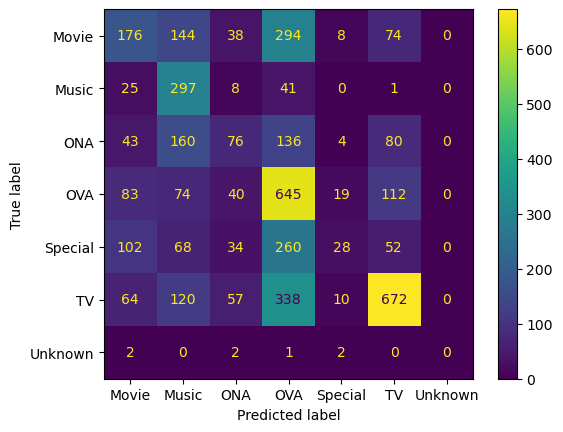

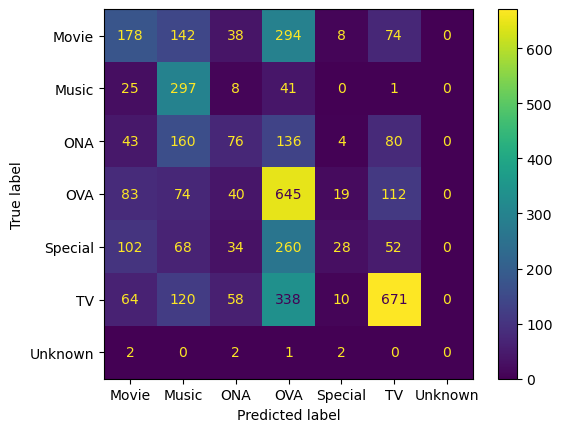

In [19]:
# Put your confusion matrix calls here.
# BEGIN SOLUTION
####################
# Exemplary answer #
####################
cm1 = confusion_matrix(test_target, y_pred_1)
cm2 = confusion_matrix(test_target, y_pred_2)

# Plotting the confusion matrix for Model 1
ConfusionMatrixDisplay.from_estimator(estimator=logistic_model1, X=test_data, y=test_target)

# Plotting the confusion matrix for Model 2
ConfusionMatrixDisplay.from_estimator(estimator=logistic_model2, X=X_test_2, y=test_target)

# END SOLUTION

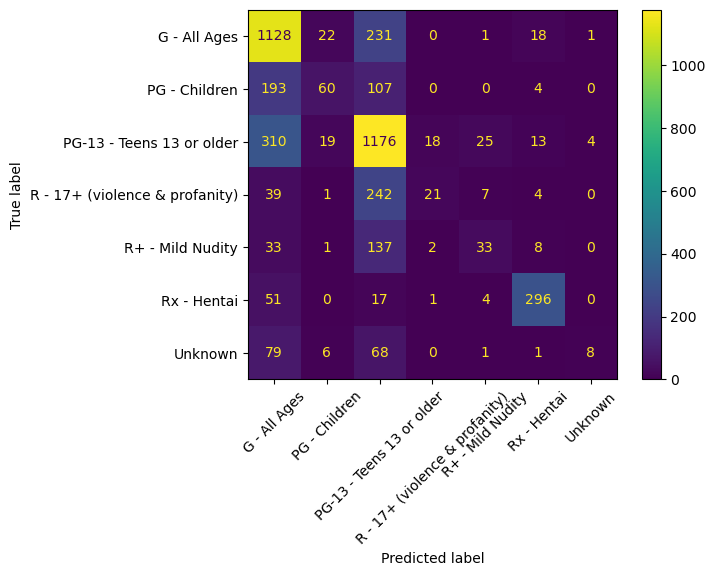

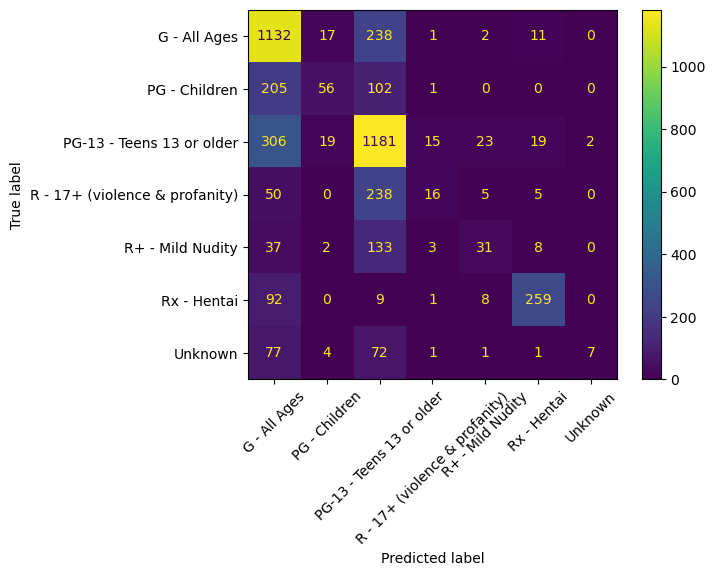

Columns: ['Rating', 'Studios', 'Type', 'Genre Count', 'Source']
Enough columns? True
Number of unique values in Rating column unfiltered table: 7
Model 1 Accuracy: 0.6200455580865604
Model 2 Accuracy: 0.6109339407744875


In [20]:
# BEGIN SOLUTION NO PROMPT
#######################
# Satisfactory answer #
#######################
# Note code is all in a single cell for ease of use. This is not why it is a Satisfactory.
# Prepare your data
col_cat = 'Rating'

all_cols5 = [
    col_cat,
    'Studios', 
    'Type', 
    'Genre Count',
    'Source' 
]

# Build models
data = anime[all_cols5]
X = data.drop(columns=['Rating'])
y = data['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=999)

categorical_cols = ['Studios', 'Type', 'Source']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

numerical_cols = ['Genre Count']
X_train_final = np.hstack((X_train_encoded, X_train[numerical_cols].values.reshape(-1, 1)))
X_test_final = np.hstack((X_test_encoded, X_test[numerical_cols].values.reshape(-1, 1)))

model_1 = LogisticRegression(max_iter=10000)
model_1.fit(X_train_final, y_train)
predictions_1 = model_1.predict(X_test_final) 
accuracy_model1 = accuracy_score(y_test, predictions_1)

X_train_2 = X_train.drop(columns=['Genre Count'])
X_test_2 = X_test.drop(columns=['Genre Count'])

X_train_categorical_2 = encoder.fit_transform(X_train_2[categorical_cols])
X_test_categorical_2 = encoder.transform(X_test_2[categorical_cols])

model_2 = LogisticRegression(max_iter=10000)
model_2.fit(X_train_categorical_2, y_train)
predictions_2 = model_2.predict(X_test_categorical_2)
accuracy_model2 = accuracy_score(y_test, predictions_2)

# Confusion matrix calls
ConfusionMatrixDisplay.from_estimator(
    estimator=model_1, 
    X=X_test_final, 
    y=y_test
)
plt.grid(False)
plt.xticks(rotation=45)
plt.show()

ConfusionMatrixDisplay.from_estimator(
    estimator=model_2, 
    X=X_test_categorical_2, 
    y=y_test
)
plt.grid(False)
plt.xticks(rotation=45)
plt.show()

# Leave these here to help with grading.
print('Columns:', all_cols5)
print('Enough columns?', 4 <= len(all_cols5) <= 5)
print('Number of unique values in', col_cat, 'column unfiltered table:', df_merged[col_cat].nunique())
print('Model 1 Accuracy:', accuracy_model1)
print('Model 2 Accuracy:', accuracy_model2)
# END SOLUTION

Columns: ['Type', 'Plan to Watch', 'Members', 'Favorites']
Enough columns? True
Number of unique values in Type column unfiltered table: 7
Model 1 Accuracy: 0.8651273885350318
Model 2 Accuracy: 0.8636146496815287


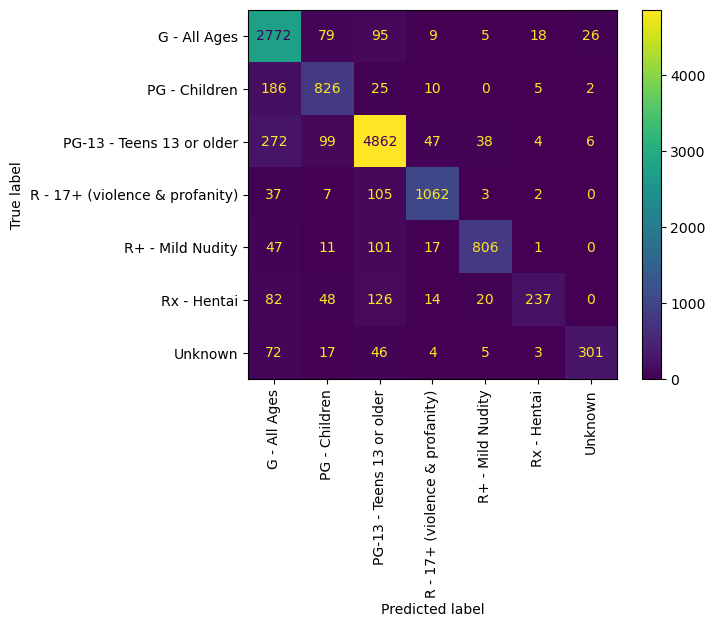

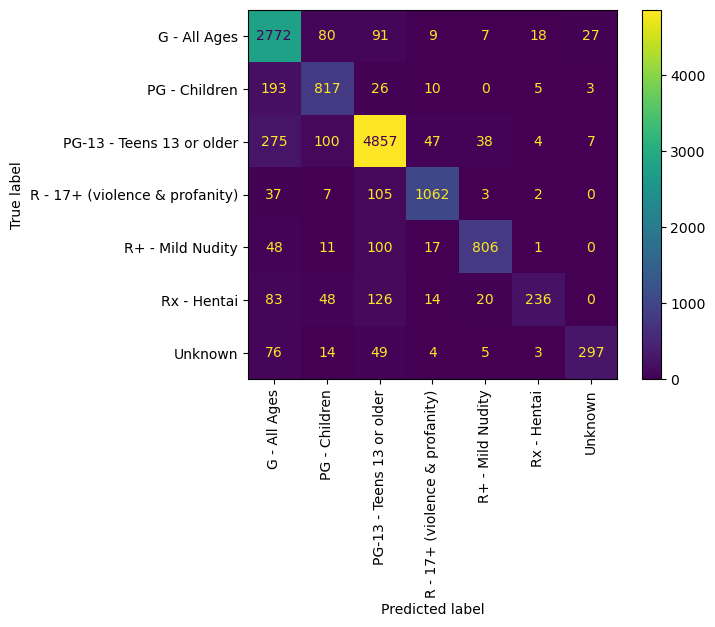

In [21]:
# BEGIN SOLUTION NO PROMPT
##################
# Not Yet answer #
##################
# Note code is all in a single cell for ease of use. This is not why it is a Not Yet.
# Prepare your data
col_cat = 'Type'
all_cols5 = [col_cat, "Plan to Watch", "Members", "Favorites"]
most_cols = ["Plan to Watch", "Members", "Favorites"]
predict = 'Rating'

# Build models
x = df_merged[most_cols].values
y = df_merged['Rating'].values

most_cols_df = df_merged[most_cols]

toAdd = OneHotEncoder().fit_transform(df_merged["Type"].to_frame()).toarray()
x = np.append(x,toAdd, axis=1)
#print(x)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

nvalues_to_try = {'n_neighbors': range(2, 8)}
knn_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=nvalues_to_try)
knn_search.fit(x_train, y_train)
best_n = knn_search.best_params_['n_neighbors']

x2 = df_merged[most_cols].values
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y, test_size=0.25, random_state=42)
knn_search2 = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=nvalues_to_try)
knn_search2.fit(x2_train, y2_train)

accuracy_model1 = knn_search.score(x_test, y_test)
accuracy_model2 = knn_search2.score(x2_test, y2_test)

# Confusion matrix calls
ConfusionMatrixDisplay.from_estimator(estimator=knn_search, X=x_test, y=y_test)
plt.xticks(rotation=90)
plt.grid(False)

ConfusionMatrixDisplay.from_estimator(estimator=knn_search2, X=x2_test, y=y2_test)
plt.xticks(rotation=90)
plt.grid(False)

# Leave these here to help with grading.
print('Columns:', all_cols5)
print('Enough columns?', 4 <= len(all_cols5) <= 5)
print('Number of unique values in', col_cat, 'column unfiltered table:', df_merged[col_cat].nunique())
print('Model 1 Accuracy:', accuracy_model1)
print('Model 2 Accuracy:', accuracy_model2)
# END SOLUTION

## Answer 4.1: Data and Model

The written part of this question is separated into **two** subparts for easier answering and grading. Please answer the questions according to the instructions below.

In cell below, discuss the following:
1. Why did you use your chosen DataFrame?
1. How did you filter, and why did you choose to keep the categories that you did? If you did not filter at all, just state as much.
1. State which model type you used and why it was a better or equally viable choice than the other two models.
1. Which columns did you choose for the data and target? And why did you choose those columns?

Note: Negative/bad results are okay, what matters is your discussion of the results.

## Answer 4.2: Results

In the cell below, discuss the following:
1. Is there a clear ranking between the models? Why or why not? If there is a ranking, what is it?
1. What do the models' performance differences tell you about the held-out column?
1. Compare 2+ values inside one confusion matrix. What do they tell you about the model?
1. Compare 2+ values between the two confusion matrices. What do they tell you about the models?

Note: Negative/bad results are okay, what matters is your discussion of the results.

**Solution**: 

### Exemplary Answer
**4.1:**
A) Why did you use your chosen DataFrame?

I chose the `anime` dataframe because it contains the relevant features needed for the classifications task, including the target variable `Type` with a more than sufficient number of data points of 17557, which makes it suitable for multi-class classification problem. I chose not to use `df_merge` because the anime data already has enough data and I didn't think it was necessary to use the merged dataset as I am not even including genre information in the model. Moreover, the animes would be duplicated by the number of genres it has, which could skew the model in weird ways.

B) How did you filter, and why did you choose to keep the categories that you did? If you did not filter at all, just state as much.

I selected the `Type` column because it has exactly 7 unique categories, which removes the need to filter the data since this doesn't exceed the question's 7 category limit. This also means there are much more than 300 rows in the DataFrame.

C) State which model type you used and why.

I used the logistic regression model because of its effectiveness in multi-class classification problems and its interpretability. Compared to the other options, such as Naive Bayes models, it tends to perform better when the assumption of feature independence is not met. K nearest neighbors was not chosen because of its higher computational cost, especially when working with larger number of features and instances and the potential sensitivity to irrelevant features. Logistic regression presented as a simpler and more parsimonious model for this problem to me.

D) Which columns did you choose for the data and target? And why did you choose those columns?

For the data, I chose `Source`, `Members`, and `Watching` as my columns, which represent where the anime is originally from, the number of community members in the anime's group, and the number of users who are watching the anime, respectively. I chose to use a one hot encoder on the `Source` column because it likely contains information that can predict the `Type` of anime. Also, `Members` could indicate the popularity of the anime which could be associated with certain anime types, and `Watching` might correlate to types of anime that engage people currently. I just thought these columns could be appropriate, useful variables for predicting the type of anime.

**4.2:**
A) Is there a clear ranking between the models? Why or why not? If there is a ranking, what is it?

There is not a clear ranking between the models. Model 2's accuracy is only 0.02% higher than Model 1, which is very small, so I don't think one model is particularly better than the other.

B) What do the models' performance differences tell you about the held-out column?

There is only a small performance difference between the two models, which tells us that the held-out column does not provide any notable additional information that is useful for classification. The held-out column does not add to the model predictive power because the accuracies are too similar to each other.

C) Compare 2+ values inside one confusion matrix. What do they tell you about the model?

Looking at the confusion matrix for model 1 we can see a correct classification for `TV` with 672 instance (predicted = TV, true label = TV). When looking at the `Movie` we can see that it was often misclassified as `OVA` 294 times (predicted = TV, true label = Movie). This is suggesting that the feature distinguishing `Movie` and `OVA` are not being effectively captured by the model or that these types of anime share similar traits, which are leading to classification errors. Also, when looking at all the numbers together, there is a clear imbalance between the classes, with Unknown being the least common and `TV` being the most and `OVA` in a close second, so in some ways it's not surprising the model was best at predicting these.

D) Compare 2+ values between the two confusion matrices. What do they tell you about the models?

Looking at the classification of `OVA` true value, we can see that model 1 correctly identified it 645 times while model 2 also correctly classified `OVA` 645 times. This means that the `Source` feature's exclusion from Model 2 did not impact the model's ability to identify `OVA` as a category. This could suggest that while the `Source` feature may carry some informative signals for certain categories or overall predictive accuracy, it may not be crucial for distinguishing `OVA` from other categories. The stability in correct classification for `OVA` between the two models indicates that other features in the models are sufficient to capture the information needed to identify `OVA` without the need for `Source`.

#### Rubric
Code Exemplary:
1. `col_cat` is a categorical column, it is what the models classified, and there are 2-7 unique values to classify
2. `all_cols5` includes `col_cat` and 3-4 other columns for a total of 4-5 columns
3. Uses the same kind of classification model (logistic regression, Naive Bayes, or KNN)
4. Split the data test and train with **25%** test, if called split twice should set random state unless they mention they didn't in the writeup and explain why
5. Models only trained on the **training** set
6. Correctly builds both models, including if using cross-fold validation to find hyperparameters for KNN (default for Naive Bayes is okay)
7. Plots a confusion matrix and puts the accuracy in `accuracy_model`* for each model using the **test** set
8. Prints out hyperparameter if used one
9. Answer is clean and easy to read

Writeup Exemplary:
1. Rationale for chosen DataFrame is reasonable and explains how data was filtered
2. States which model is used and it matches the code
3. Rationale for the model is reasonable and discusses why the other models are/are not viable
4. Rationale for columns is reasonable
5. If used cross-fold validation, report the found hyperparameter OR it's clearly labeled and printed out
6. Compares the models in terms of both their accuracy scores and confusion matrices, discusses the results' reasonableness, and explanation why is reasonable. If did anything unusual (used an encoder, etc.), it should be discussed.
7. Discussion comparing the values inside of the same confusion matrix is reasonable
8. Discussion comparing the values between the confusion matrices is reasonable
9. Answer is clean and easy to read

### Satisfactory Answer
**4.1:**

A. We used the anime DataFrame because we didn't want duplicate animes and we aren't using genres in our model.

B. We did not filter because our predicted category `Rating` has only 7 categories. To predict rating we used the variables `Studios`, `Type`, `Genre Count`, and `Source` because these attributes are crucial in understanding the characteristics of the anime that may influence its content rating, such as the type of studio involved, the source of content, and the variety of genres covered.

C. We chose logistic regression because it is well-suited for making predictions about categorical outcomes like the content rating, and it is simple and effective. It is also easier to implement than Naive Bayes and k-nearest neighbors, making it a suitable choice.

D. The data columns chosen were `Studios`, `Type`, `Genre Count`, and `Source` as these features likely affect the content rating by reflecting the production quality, content type, thematic complexity, and origin. The target variable was `Rating`, as the goal was to predict the content suitability category based on the aforementioned features.

**4.2:**

A. There is no clear ranking between Model 1 and Model 2 in terms of accuracy; their accuracies are almost identical, with Model 1 being slightly higher at 62.1% compared to Model 2 at 61.1%. This suggests that both models perform similarly.

B. The minute difference in performance tells us that the held-out column in Model 2, `Genre Count`, did not significantly contribute to predicting the anime ratings.

C. In the confusion matrix for either model, the diagonal values represent the number of correct predictions for each class. For example, `PG-13 - Teens 13 or older` shows a high number of correct predictions (1,177 and 1,181), suggesting the model performs well for this category. In contrast, categories such as `R+ - Mild Nudity` and `Rx - Hentai` have lower correct predictions, indicating the model struggles more with these classes.

D. Comparing values across the confusion matrices, one can notice that both models have similar patterns of correct and incorrect predictions. For instance, both models appear to confuse `G - All Ages` with `PG-13 - Teens 13 or older`. This similarity further indicates that the held-out column does not have a substantial impact on the model's ability to distinguish between these classes.

**Explanation of grade:** This was borderline Satisfactory/NotYet. The code and write up are not clean because the code copies and pastes the column names rather than using the values in the list. The write up is unnecessarily repetitive (Parts B and D have some of the same information even though only part D needed it). The choice for Logistic Regression is vague and equally true for any classifier. The answer needs to demonstrate some understanding of how the models are different or the same. Moreover, this answer does not follow directions for the last question discussing particular numbers in the confusion matrices. But it did not get a Not Yet since it's clear they understand what the numbers mean. However, the lack of pointing out that there are more anime for some ratings compared to others is problematic, since some of the text seems to be inferring that lower numbers means poorer at predicting that rating rather than simply there weren't that many of that animes with that rating to begin with.

#### Rubric
Code Satisfactory: Must have #3, #5, #6, #7
1 - If messed up, it's fine as long as it's clear what the value of `col_cat` is  
2 - `all_cols5` has up to 15 columns OR messed up in filling this out but it's clear what the values should be  
4 - Okay if used a different value than 25% OR splits test/train for each model separately  
8 - Okay if forgot, but reported it in the write-up  
9 - Answer is not clean and easy to read  

Writeup Satisfactory: Must have #2  
1 - Can be missing if no filtering was done, otherwise must be present, but rationale for chosen dataframe must still be reasonable  
3 - The rationale for the model is a little off, but still mentions all three model types and there are no incorrect statements  
4 - One of the column's rationales is not reasonable  
5 - No mention in the writeup of the hyperparameter and the code prints it somewhere but it's not clearly labeled  
6 - It's a little off. There are no incorrect statements. Could be missing one of the three parts of: accuracy score, confusion matrix, and general reasonableness of the results  
7 and 8 - One of these is incomplete/missing, but no incorrect statements  
9 - Answer is not clean and easy to read  

### Not Yet Answer
**4.1:**

A. We chose to use the `df_merged` DateFrame because there is more information in this data frame than the `anime` DataFrame. However, we did not take advantage of this in the model as we did not utilize the extra information that the `df_merged` DataFrame provided.

B. We did not need to filter the categories because the column that we chose, `Type`, already has seven categories.

C. We chose to use the K Nearest Neighbors model. We chose this model because it does not assume anything about the data and it is very flexible for various data types. It can also handle multiple class classification, which is benificial in this instance for predicting anime genres with multiple different columns of data.

D. The columns we chose for data were `Plan to Watch`, `Members`, `Favorites`, and `Type`. The target column is `Rating`. We chose the columns `Plan to Watch`, `Members`, and `Favorites` because they are markers of popularity, which may correlate with age. In addition, these columns are numerical data, which is easier to work with. We chose the `Type` column because there were not a lot of categories within the type, and the `Type` may correlate with an age range when choosing the mode of consumption for anime. This may be beneficial for predicting the age range an anime will be rated for. We chose the `Rating` column as our target because there are seven different categories, which is a small number of possibilities which makes it easier to predict, and we felt that out data columns that we chose could represent the possible age rating of the `Rating` column well.

**4.2:**

A. No, Model A is marginally better than Model B, but the difference is so small that there is no clear ranking between the models, especially considering that Model A contains an extra column.

B. The models' performance suggests that the held-out column does not have much predictive power for Rating.

C. In the first confusion matrix, the model correctly predicted `PG-13` 4862 times and predicted a rating `G` when the true label was `PG-13` 272 times. Most of the time, the model was correct in predicting `PG-13` movies, but 272 times it was wrong and predicted `G`. This is more than any other false predictions for a true label of `PG-13`. This tells us our model performed well, and shows us where the model made mistakes when it did not correctly predict rating.

D. In the first confusion matrix, the model correctly predicted `G` rating 2772 times, and in the second confusion matrix, the model correctly predicted `G` rating 2772 times. These numbers are the same, which helps show that the two models performed similarly.

**Explanation of grade:** The code is not clean because the code copies and pastes the column names rather than using the values in the list/variable. The code also do not follow directions in what the value of `col_cat` should be and throughout clearly misunderstood some of the question requirements. There is no discussion of whether the other model types are/are not viable options. In addition, the rationale for the chosen dataframe when using df_merge does not consider that animes are now weighted per genre. The write-up states that the column has no predictive power, which is incorrect and cannot be inferred from the results here. All we know is that column doesn't add to the model given the columns already in the model. Finally, the writeup is unnecessarily repetitive and hard to read.

#### Rubric
Not yet: Work that does not meet some requirements and/or displays developing or incomplete mastery of at least some learning goals and material.

### Unassessable Rubric
Unassessable: Work that is missing, does not demonstrate meaningful effort, or does not provide enough evidence to determine a level of mastery.

## Submitting

You should make sure any code that you write to answer the questions is included in this notebook. You are **strongly encouraged** to go to the Kernel option and choose **"Restart & Run All"**  before submission. Double check that your entire notebook runs correctly and generates the expected output. Finally, make sure to save your work (timestamp at the top tells you the last checkpoint and whether there are unsaved changes). When you finish, submit your assignment at [Gradescope](http://gradescope.com/ "‌"). **Submissions not prepared correctly as above may lose points.**